<a href="https://colab.research.google.com/github/sumin031130/ESAA/blob/main/Colab_%EC%8B%9C%EC%9E%91%ED%95%98%EA%B8%B0%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 분석

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving movies_train.csv to movies_train.csv


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
train =  pd.read_csv('movies_train.csv')

## 감독 데뷔 여부(전에 찍은 작품수가 0인 감독과 아닌 감독) × 관객수

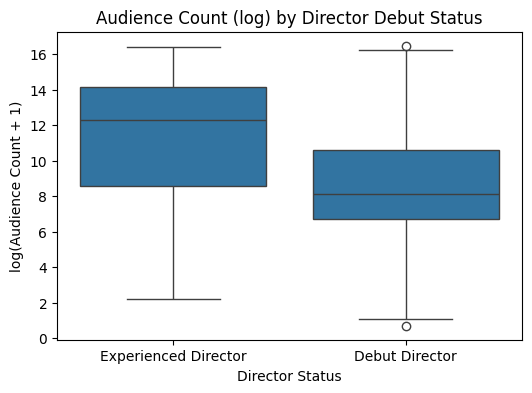

            median          mean  count
is_debut                               
False     222258.0  1.146932e+06    270
True        3401.5  3.492043e+05    330


In [ ]:
train['is_debut'] = train['dir_prev_num'] == 0
train['log_box_off'] = np.log1p(train['box_off_num'])

plt.figure(figsize=(6,4))
sns.boxplot(x='is_debut', y='log_box_off', data=train)
plt.xticks([0,1], ['Experienced Director', 'Debut Director'])
plt.title('Audience Count (log) by Director Debut Status')
plt.xlabel('Director Status')
plt.ylabel('log(Audience Count + 1)')
plt.show()

print(train.groupby('is_debut')['box_off_num'].agg(['median','mean','count']))

### 결론
- 감독의 데뷔 여부는 관객수와 뚜렷한 관계를 보임
- 경력감독 작품의 중앙값(222,258명)은 데뷔감독 작품(3,402명)의 약 65배에 달하며, 박스플롯 상 두 그룹의 IQR이 거의 겹치지 않을 정도로 분포가 뚜렷이 구분된다.
- 다만 데뷔감독 그룹에서도 이상치 비율(17.9%)이 더 높게 나타나는 점을 볼 때, 데뷔감독의 흥행은 "대부분 저조하지만 일부는 대박"인 양극화 양상을 보이는 반면 경력감독은 상대적으로 안정적인 흥행 범위를 형성한다고 볼 수 있다.


---
## 상영시간 x 스탭수

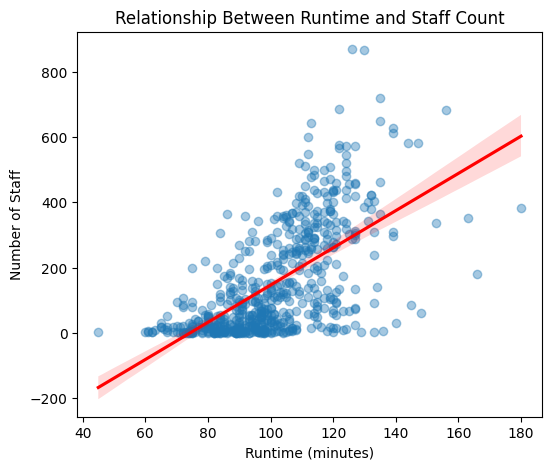

Correlation coefficient: 0.623


In [ ]:
plt.figure(figsize=(6,5))
sns.regplot(x='time', y='num_staff', data=train,
            scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title('Relationship Between Runtime and Staff Count')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Number of Staff')
plt.show()

corr = train['time'].corr(train['num_staff'])
print(f"Correlation coefficient: {corr:.3f}")

In [ ]:
# 0~25% / 25~75% / 75% 이상
bins = [0, 90, 120, 180]
labels = ['Short (~90min)', 'Medium (90-120min)', 'Long (120min+)']
train['time_cat'] = pd.cut(train['time'], bins=bins, labels=labels)

print(train.groupby('time_cat')['num_staff'].agg(['median','mean','count']))

                    median        mean  count
time_cat                                     
Short (~90min)        17.0   42.111111    180
Medium (90-120min)   120.5  166.326471    340
Long (120min+)       335.0  331.750000     80


/tmp/ipykernel_1141/1939416154.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(train.groupby('time_cat')['num_staff'].agg(['median','mean','count']))


###  결론
- 상영시간과 스탭수 사이에는 뚜렷한 양의 상관관계가 존재(r=0.623, p<0.001)
- 상영시간을 짧음/보통/장편 세 구간으로 나누어 비교했을 때 스탭수 중앙값이 17명 → 120.5명 → 335명으로 단계적으로 증가하는 것을 확인할 수 있다

=> 이는 상영시간이 긴 영화일수록 제작 규모(인력 투입)가 커진다는 것을 시사하며, 상영시간이 영화의 "제작 스케일"을 나타내는 대리지표(proxy) 역할을 할 수 있음을 보여준다.


---
## 장르에 따른 스탭수 변화

/tmp/ipykernel_1141/3189499776.py:10: UserWarning: Glyph 50529 (\N{HANGUL SYLLABLE AEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/3189499776.py:10: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/3189499776.py:10: UserWarning: Glyph 45712 (\N{HANGUL SYLLABLE NEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/3189499776.py:10: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/3189499776.py:10: UserWarning: Glyph 47476 (\N{HANGUL SYLLABLE REU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/3189499776.py:10: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/3189499776.py:10: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_la

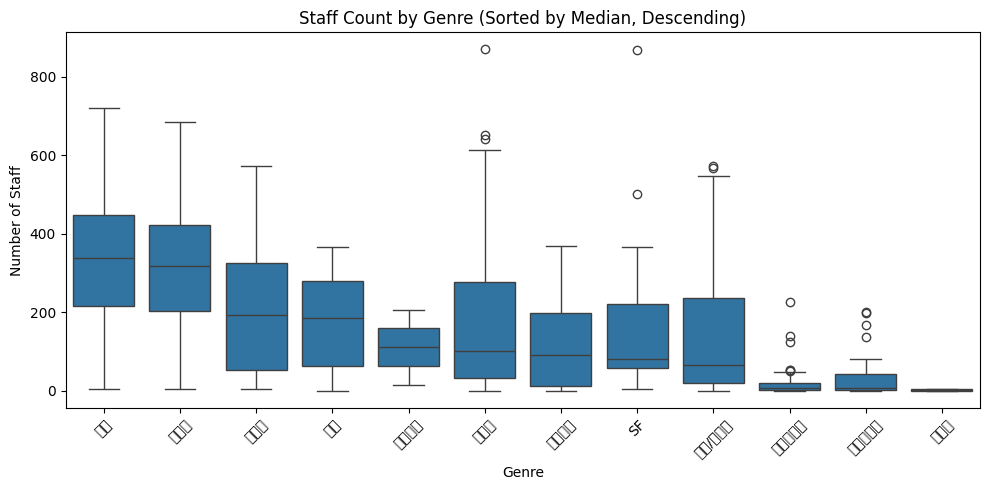

        median        mean  count
genre                            
액션       338.5  337.535714     28
느와르      319.0  311.074074     27
코미디      192.0  209.075472     53
공포       185.5  176.380952     42
서스펜스     111.0  111.000000      2
드라마      101.0  164.484163    221
미스터리      92.0  117.352941     17
SF        82.0  197.307692     13
멜로/로맨스    66.5  135.782051     78
다큐멘터리      8.0   17.849462     93
애니메이션      8.0   44.619048     21
뮤지컬        3.0    2.200000      5


In [ ]:
order = train.groupby('genre')['num_staff'].median().sort_values(ascending=False).index

# Boxplot (ordered by median)
plt.figure(figsize=(10,5))
sns.boxplot(x='genre', y='num_staff', data=train, order=order)
plt.title('Staff Count by Genre (Sorted by Median, Descending)')
plt.xlabel('Genre')
plt.ylabel('Number of Staff')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(train.groupby('genre')['num_staff'].agg(['median','mean','count']).sort_values('median', ascending=False))

/tmp/ipykernel_1141/387915850.py:10: UserWarning: Glyph 50529 (\N{HANGUL SYLLABLE AEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/387915850.py:10: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/387915850.py:10: UserWarning: Glyph 45712 (\N{HANGUL SYLLABLE NEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/387915850.py:10: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/387915850.py:10: UserWarning: Glyph 47476 (\N{HANGUL SYLLABLE REU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/387915850.py:10: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/387915850.py:10: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


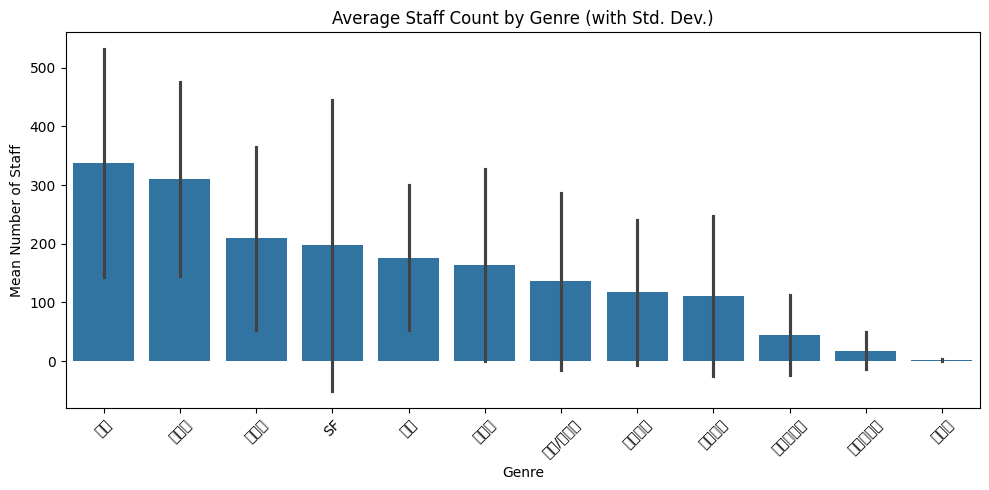

              mean         std  count
genre                                
액션      337.535714  193.757482     28
느와르     311.074074  165.196369     27
코미디     209.075472  156.540342     53
SF      197.307692  247.975598     13
공포      176.380952  123.022098     42
드라마     164.484163  163.701880    221
멜로/로맨스  135.782051  151.217797     78
미스터리    117.352941  123.666862     17
서스펜스    111.000000  135.764502      2
애니메이션    44.619048   68.752074     21
다큐멘터리    17.849462   31.258719     93
뮤지컬       2.200000    2.049390      5


In [ ]:
# Barplot (mean comparison, ordered by mean)
order_mean = train.groupby('genre')['num_staff'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10,5))
sns.barplot(x='genre', y='num_staff', data=train, order=order_mean, estimator='mean', errorbar='sd')
plt.title('Average Staff Count by Genre (with Std. Dev.)')
plt.xlabel('Genre')
plt.ylabel('Mean Number of Staff')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(train.groupby('genre')['num_staff'].agg(['mean','std','count']).sort_values('mean', ascending=False))

In [ ]:
from scipy import stats
groups = [g['num_staff'].values for _, g in train.groupby('genre')]
stat, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis H={stat:.2f}, p={p:.2e}")

Kruskal-Wallis H=195.98, p=5.07e-36


### 결론
- 액션(338.5명)·느와르(319명)가 압도적으로 많고, 뮤지컬(3명)·다큐멘터리(8명)·애니메이션(8명)이 바닥. 최대-최소 격차가 약 113배
- Kruskal-Wallis 검정 결과(p=5.07e-36)도 이 차이가 우연이 아니라는 걸 강하게 뒷받침해.

- 액션·느와르는 촬영 스케일이 크고(스턴트팀, 특수효과, 다수 엑스트라 등) 인력이 많이 필요한 장르
- 다큐멘터리는 인터뷰이·소규모 촬영팀 위주라 스탭 수 자체가 작고
- 애니메이션은 실사 촬영 스탭이 거의 필요 없어서(작화팀은 여기 num_staff 집계에 다르게 반영될 수도 있음) 낮게 나오는 걸로 보임

- 2번 아이디어와도 자연스럽게 연결돼: 상영시간이 길수록 스탭이 많다는 걸 확인했는데, 만약 액션/느와르 영화가 평균적으로 더 길다면 "장르가 스탭수에 미치는 영향"의 일부는 사실 "상영시간을 매개로 한 간접효과"일 수도 있음

- 주의할 점 하나: 서스펜스(n=2), 뮤지컬(n=5)은 표본이 너무 적어서 이 그룹의 "중앙값"은 신뢰하기 어려움— "표본수가 극히 적은 장르는 해석에 주의"

/tmp/ipykernel_1141/718741075.py:10: UserWarning: Glyph 45712 (\N{HANGUL SYLLABLE NEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/718741075.py:10: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/718741075.py:10: UserWarning: Glyph 47476 (\N{HANGUL SYLLABLE REU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/718741075.py:10: UserWarning: Glyph 50529 (\N{HANGUL SYLLABLE AEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/718741075.py:10: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/718741075.py:10: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/718741075.py:10: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

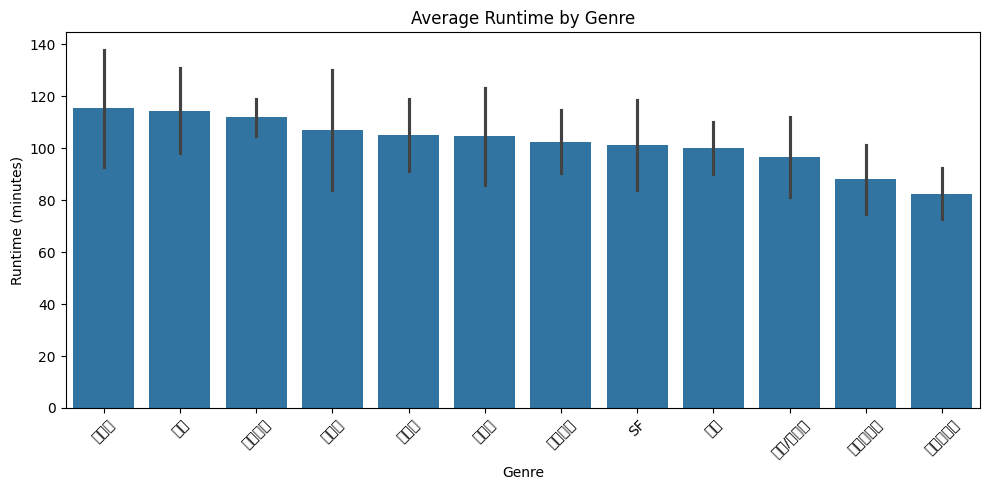

              mean  median  count
genre                            
느와르     115.370370   111.0     27
액션      114.464286   113.5     28
서스펜스    112.000000   112.0      2
뮤지컬     107.000000   100.0      5
코미디     105.264151   108.0     53
드라마     104.651584   104.0    221
미스터리    102.588235    99.0     17
SF      101.384615   100.0     13
공포      100.214286    99.0     42
멜로/로맨스   96.641026    94.5     78
다큐멘터리    88.053763    87.0     93
애니메이션    82.571429    83.0     21


In [ ]:
# cf) 장르별 평균 상영시간
order = train.groupby('genre')['time'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10,5))
sns.barplot(x='genre', y='time', data=train, order=order, estimator='mean', errorbar='sd')
plt.title('Average Runtime by Genre')
plt.xlabel('Genre')
plt.ylabel('Runtime (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(train.groupby('genre')['time'].agg(['mean','median','count']).sort_values('mean', ascending=False))

In [ ]:
from scipy import stats
groups = [g['time'].values for _, g in train.groupby('genre')]
stat, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis H={stat:.2f}, p={p:.2e}")

Kruskal-Wallis H=127.21, p=6.37e-22


In [ ]:
staff_rank = train.groupby('genre')['num_staff'].mean().rank(ascending=False)
time_rank = train.groupby('genre')['time'].mean().rank(ascending=False)
print(pd.DataFrame({'time_rank': time_rank, 'staff_rank': staff_rank}))

        time_rank  staff_rank
genre                        
SF            8.0         4.0
공포            9.0         5.0
느와르           1.0         2.0
다큐멘터리        11.0        11.0
드라마           6.0         6.0
멜로/로맨스       10.0         7.0
뮤지컬           4.0        12.0
미스터리          7.0         8.0
서스펜스          3.0         9.0
애니메이션        12.0        10.0
액션            2.0         1.0
코미디           5.0         3.0


---
## 장르에 따른 관객수

/tmp/ipykernel_1141/1386168625.py:10: UserWarning: Glyph 45712 (\N{HANGUL SYLLABLE NEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/1386168625.py:10: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/1386168625.py:10: UserWarning: Glyph 47476 (\N{HANGUL SYLLABLE REU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/1386168625.py:10: UserWarning: Glyph 50529 (\N{HANGUL SYLLABLE AEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/1386168625.py:10: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/1386168625.py:10: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1141/1386168625.py:10: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_la

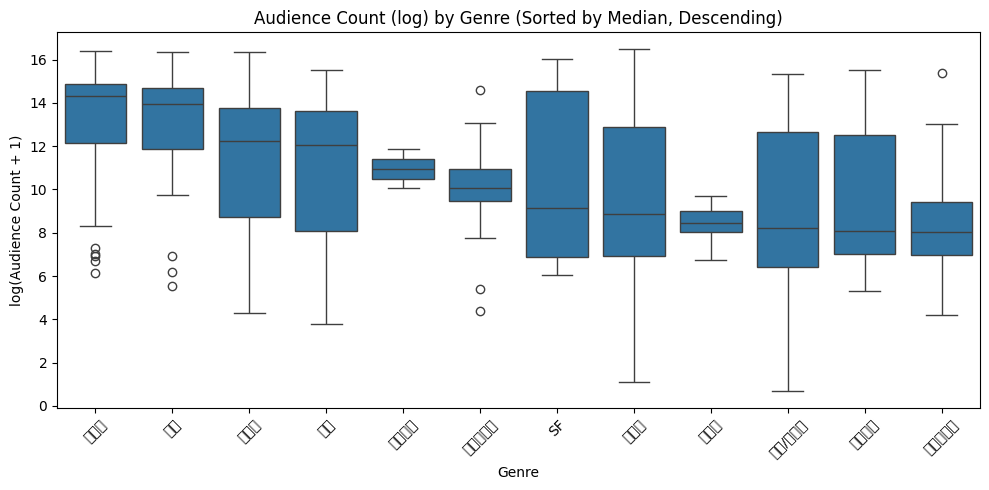

           median          mean  count
genre                                 
느와르     1646142.0  2.263695e+06     27
액션      1147846.5  2.203974e+06     28
코미디      210775.0  1.193914e+06     53
공포       179810.0  5.908325e+05     42
서스펜스      82611.0  8.261100e+04      2
애니메이션     23802.0  1.819267e+05     21
SF         9323.0  1.788346e+06     13
드라마        7173.0  6.256898e+05    221
뮤지컬        4778.0  6.627000e+03      5
멜로/로맨스     3653.0  4.259680e+05     78
미스터리       3199.0  5.275482e+05     17
다큐멘터리      3044.0  6.717226e+04     93


In [ ]:
train['log_box_off'] = np.log1p(train['box_off_num'])
order = train.groupby('genre')['box_off_num'].median().sort_values(ascending=False).index

plt.figure(figsize=(10,5))
sns.boxplot(x='genre', y='log_box_off', data=train, order=order)
plt.title('Audience Count (log) by Genre (Sorted by Median, Descending)')
plt.xlabel('Genre')
plt.ylabel('log(Audience Count + 1)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(train.groupby('genre')['box_off_num'].agg(['median','mean','count']).sort_values('median', ascending=False))

In [ ]:
from scipy import stats
groups = [g['box_off_num'].values for _, g in train.groupby('genre')]
stat, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis H={stat:.2f}, p={p:.2e}")

Kruskal-Wallis H=81.76, p=6.75e-13


### 결론
느와르(중앙값 1,646,142명)·액션(1,147,846명)이 압도적 1·2위, 다큐멘터리(3,044명)·미스터리(3,199명)가 최하위. 최대-최소 격차 약 540배. H=81.76, p=6.75e-13으로 통계적으로 매우 유의.

3번 분석(장르별 스탭수)과 순위를 비교해보면 흥미로운 게, 느와르·액션이 스탭수 1·2위였고 관객수도 1·2위로 정확히 겹쳐. 반면 SF는 스탭수 중앙값이 82명으로 낮은 편(8위)인데 관객수 평균은 1,788,346명으로 꽤 높게 나와 — 이건 SF가 n=13으로 표본이 적은 데다, 소수의 흥행작(아마 대작 SF 한두 편)이 평균을 확 끌어올린 걸로 보여(중앙값은 9,323명으로 평균과 극단적으로 차이 남 — 이것도 "평균 vs 중앙값" 문제의 또 다른 사례).

---
## 배급사별(Top6 와 나머지) 관객수 비교

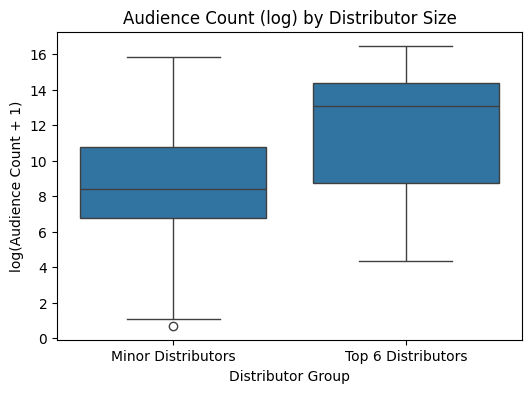

                 median          mean  count
is_major_dist                               
False            4449.0  2.325812e+05    383
True           472695.0  1.547606e+06    217


In [ ]:
distributor_counts = train['distributor'].value_counts()
major_distributors = distributor_counts[distributor_counts >= 26].index
train['is_major_dist'] = train['distributor'].isin(major_distributors)

plt.figure(figsize=(6,4))
sns.boxplot(x='is_major_dist', y='log_box_off', data=train)
plt.xticks([0,1], ['Minor Distributors', 'Top 6 Distributors'])
plt.title('Audience Count (log) by Distributor Size')
plt.xlabel('Distributor Group')
plt.ylabel('log(Audience Count + 1)')
plt.show()

print(train.groupby('is_major_dist')['box_off_num'].agg(['median','mean','count']))

In [ ]:
from scipy import stats
g1 = train[train['is_major_dist']]['box_off_num']
g2 = train[~train['is_major_dist']]['box_off_num']
u_stat, p = stats.mannwhitneyu(g1, g2, alternative='greater')
print(f"Mann-Whitney U={u_stat:.0f}, p={p:.2e}")

Mann-Whitney U=61920, p=9.20e-24


### 결론
중앙값 기준 약 106배 차이. 두 그룹이 정규분포가 아니라서 t-test 대신 순위 기반 검정인 Mann-Whitney U 검정을 썼는데, U=61920, p=9.20e-24로 상위 배급사 그룹의 관객수가 통계적으로 유의하게 높음. 100만 관객 돌파 비율도 상위 배급사 37.3% vs 기타 7.3%로 5배 차이.